In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np
import plotly.graph_objects as go
import pandas as pd
import geopandas as gpd
from geopandas import GeoDataFrame
from shapely.geometry import Point
import datetime as dt
import cv2
import os

In [2]:
folder = os.getcwd()
filename = "earthquakes1970-2013.csv_imp.csv"
path = os.path.join(folder, filename)

# Load CSV
df = pd.read_csv(path)

# Create geometry from Longitude/Latitude
geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]

# Convert to GeoDataFrame
earthquakes = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

print(earthquakes.head())
print(earthquakes.crs)

                  DateTime  Day  Month  Year  Hour  Latitude  Longitude  \
0  1970-01-04 17:00:40.200    4      1  1970    17    24.139    102.503   
1  1970-01-06 05:35:51.800    6      1  1970     5    -9.628    151.458   
2  1970-01-08 17:12:39.100    8      1  1970    17   -34.741    178.568   
3  1970-01-10 12:07:08.600   10      1  1970    12     6.825    126.737   
4  1970-01-16 08:05:39.000   16      1  1970     8    60.280   -152.660   

   Depth  Magnitude MagType  NbStations  RMS Source                 geometry  
0   31.0        7.5      Ms        90.0  0.0    NEI   POINT (102.503 24.139)  
1    8.0        6.2      Ms        85.0  0.0    NEI   POINT (151.458 -9.628)  
2  179.0        6.1      Mb        59.0  0.0    NEI  POINT (178.568 -34.741)  
3   73.0        6.1      Mb        91.0  0.0    NEI    POINT (126.737 6.825)  
4   85.0        6.0      ML         0.0  0.0     AK    POINT (-152.66 60.28)  
EPSG:4326


# VISUALIZE WORLD EARTHQUAKES WITH PLATE BOUNDARIES

EPSG:4326


/tmp/ipykernel_76507/1242987929.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


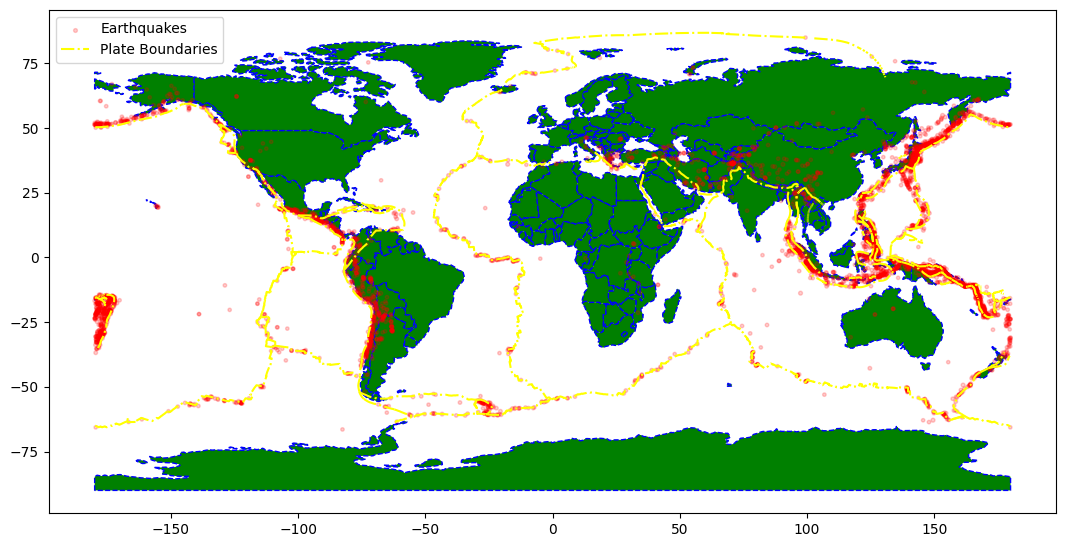

In [3]:
# Import world shp
world = gpd.read_file("../ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
plates = gpd.read_file("../Plate_Boundaries/Plate_Boundaries.shp")

# Identify CRS compatibility (If we need CRS re-projection)
print(world.crs)

# Create figure and axis with size
fig, ax = plt.subplots(figsize=(13, 10))

# World boundaries
world.plot(
    ax=ax,
    color="green",
    linestyle="--",
    edgecolor="blue",
    label="World Boundaries"
)

# Earthquake points (bubble size by magnitude)
earthquakes.plot(
    ax=ax,
    markersize=earthquakes["Magnitude"],
    color="red",
    alpha=0.2,
    label="Earthquakes"
)

# Plate boundaries
plates.plot(
    ax=ax,
    color="yellow",
    alpha=1,
    linestyle="dashdot",
    label="Plate Boundaries"
)

# Add legend
ax.legend()
plt.show()

1. Plate Boundaries are exact locations of earthquakes
2. Most Earthquakes occur on **Pacific Ring of Fire** > https://www.livescience.com/planet-earth/volcanos/what-is-the-pacific-ring-of-fire

## PACIFIC RING OF FIRE

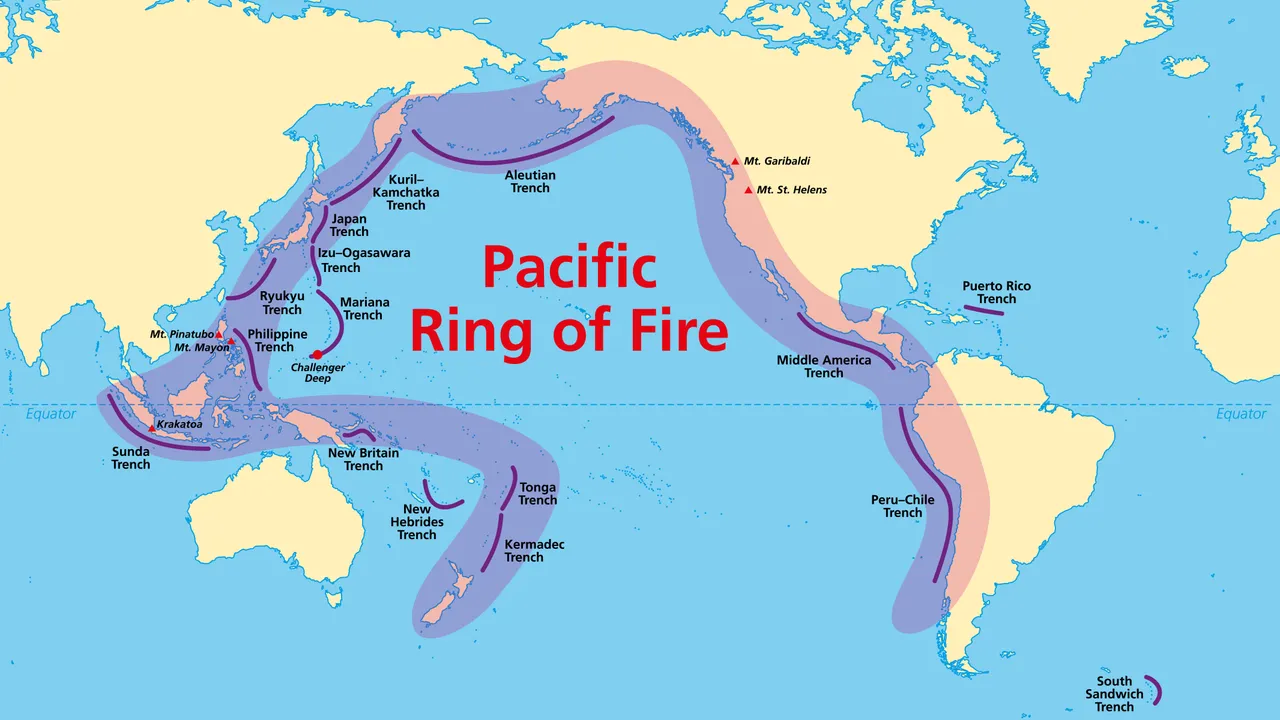

In [4]:
img = Image.open("../pacific_ring_of_fire.jpg")
img.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5302 entries, 0 to 5301
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DateTime    5302 non-null   object 
 1   Day         5302 non-null   int64  
 2   Month       5302 non-null   int64  
 3   Year        5302 non-null   int64  
 4   Hour        5302 non-null   int64  
 5   Latitude    5302 non-null   float64
 6   Longitude   5302 non-null   float64
 7   Depth       5302 non-null   float64
 8   Magnitude   5302 non-null   float64
 9   MagType     5302 non-null   object 
 10  NbStations  5302 non-null   float64
 11  RMS         5302 non-null   float64
 12  Source      5302 non-null   object 
dtypes: float64(6), int64(4), object(3)
memory usage: 538.6+ KB


# DAY VS NIGHT EARTHQUAKE OCCURED

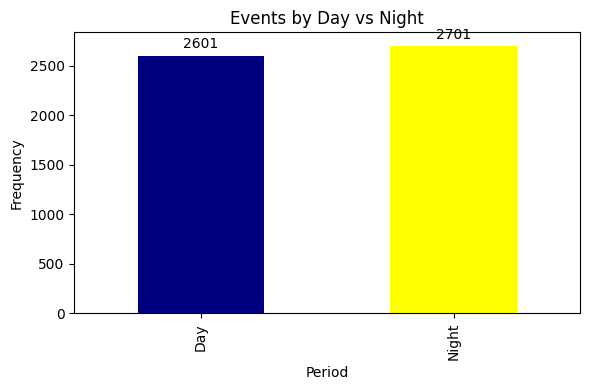

In [6]:
# Define day vs night
df["DayNight"] = df["Hour"].apply(lambda h: "Day" if 6 <= h < 18 else "Night")

# Count events in fixed order
counts = df["DayNight"].value_counts().reindex(["Day", "Night"], fill_value=0)

# Color mapping
color_map = {"Day": "navy", "Night": "yellow"}
colors = [color_map[i] for i in counts.index]

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
bars = counts.plot(kind="bar", color=colors, ax=ax)

ax.set_xlabel("Period")
ax.set_ylabel("Frequency")
ax.set_title("Events by Day vs Night")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

Earthquakes occur more frequently at night based on the bar plot. A difference of around 100 events is significant—especially considering people are typically asleep during those hours.

# MAGNITUDE DISTRIBUTION

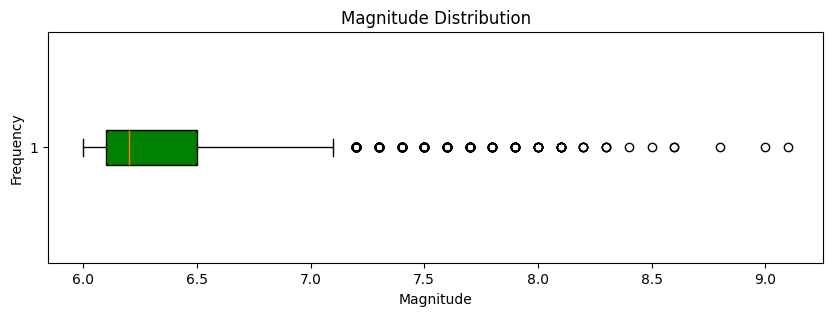

Q1: 6.1
Q3: 6.5
IQR: 0.40000000000000036


In [7]:
plt.figure(figsize=(10,3))
plt.boxplot(df["Magnitude"], patch_artist=True,
            boxprops=dict(facecolor="green"), vert=False)
plt.title("Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.show()

# Q1 (25th percentile)
Q1 = df["Magnitude"].quantile(0.25)

# Q3 (75th percentile)
Q3 = df["Magnitude"].quantile(0.75)

# IQR = Q3 - Q1
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Majority of Magnitude Distribution is 6.1 to 6.5

# EXPLORATION OF MAGNITUDE GREATER THAN 8.0

Earthquakes with magnitudes greater than 8.0 are among the most powerful natural events on Earth. Classified as “great earthquakes,” they release immense energy capable of devastating entire regions, reshaping landscapes, and triggering tsunamis across oceans. Although rare, these seismic events are critical to study because they highlight the extreme end of tectonic activity and provide valuable insights into global seismic hazards.

In [8]:
magnitudes_ge8 = df[df["Magnitude"] >= 8.0]
# Create geometry from lon/lat
geometry = gpd.points_from_xy(magnitudes_ge8["Longitude"], magnitudes_ge8["Latitude"])

# Wrap into GeoDataFrame
magnitudes_ge8_plot = gpd.GeoDataFrame(magnitudes_ge8, geometry=geometry, crs="EPSG:4326")

# Sort and preview
print(magnitudes_ge8[["Magnitude","Year","Hour"]].sort_values(by="Magnitude", ascending=False).head())

      Magnitude  Year  Hour
4829        9.1  2011     5
3761        9.0  2004     0
4638        8.8  2010     6
3827        8.6  2005    16
5048        8.6  2012     8


/tmp/ipykernel_76507/3426070060.py:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


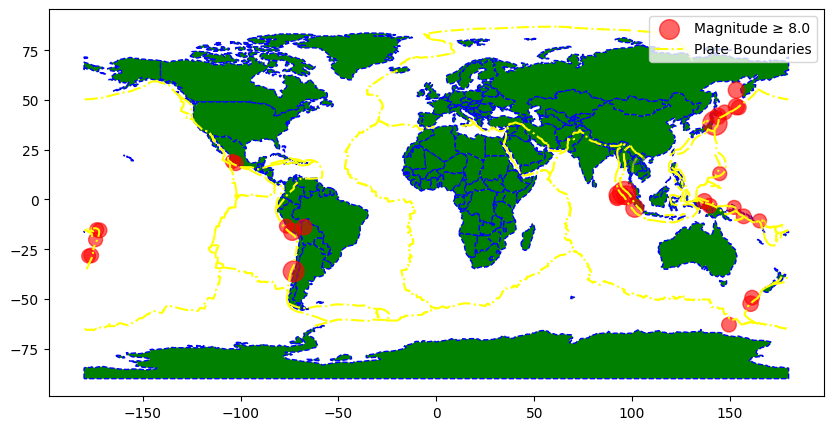

In [9]:
fig, ax = plt.subplots(figsize=(10,6))

# World boundaries
world.plot(
    ax=ax,
    color="green",
    linestyle="--",
    edgecolor="blue",
    label="World Boundaries"
)

# Earthquake points (bubble size by magnitude)
magnitudes_ge8_plot.plot(
    ax=ax,
    markersize=np.exp(magnitudes_ge8["Magnitude"] - 8.0) * 100,  # numeric array
    color="red",
    alpha=0.6,
    label="Magnitude ≥ 8.0"
)

# Plate boundaries
plates.plot(
    ax=ax,
    color="yellow",
    alpha=1,
    linestyle="dashdot",
    label="Plate Boundaries"
)

# Add legend
ax.legend()
plt.show()

# AVERAGE MAGNITUDES PER YEAR

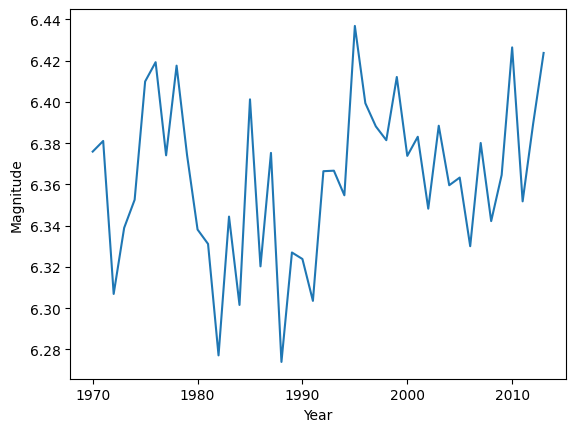

In [10]:
avg = df.groupby("Year")["Magnitude"].mean()
avg.plot()
plt.xlabel("Year")
plt.ylabel("Magnitude")
plt.show()

# AVERAGE MAGNITUDES PER MONTH

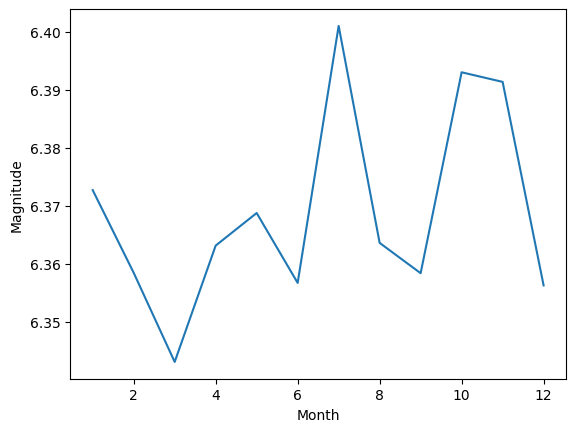

In [54]:
avg = df.groupby("Month")["Magnitude"].mean()
avg.plot()
plt.xlabel("Month")
plt.ylabel("Magnitude")
plt.show()

# MAGNITUDE VS DEPTH 

Is Magnitude Proportional to Depth?

/tmp/ipykernel_76507/2711838287.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_depth_by_mag = df.groupby("Magnitude_cat")["Depth"].mean()
/tmp/ipykernel_76507/2711838287.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Magnitude_cat", y="Depth", palette="Blues", ax=axes[1])


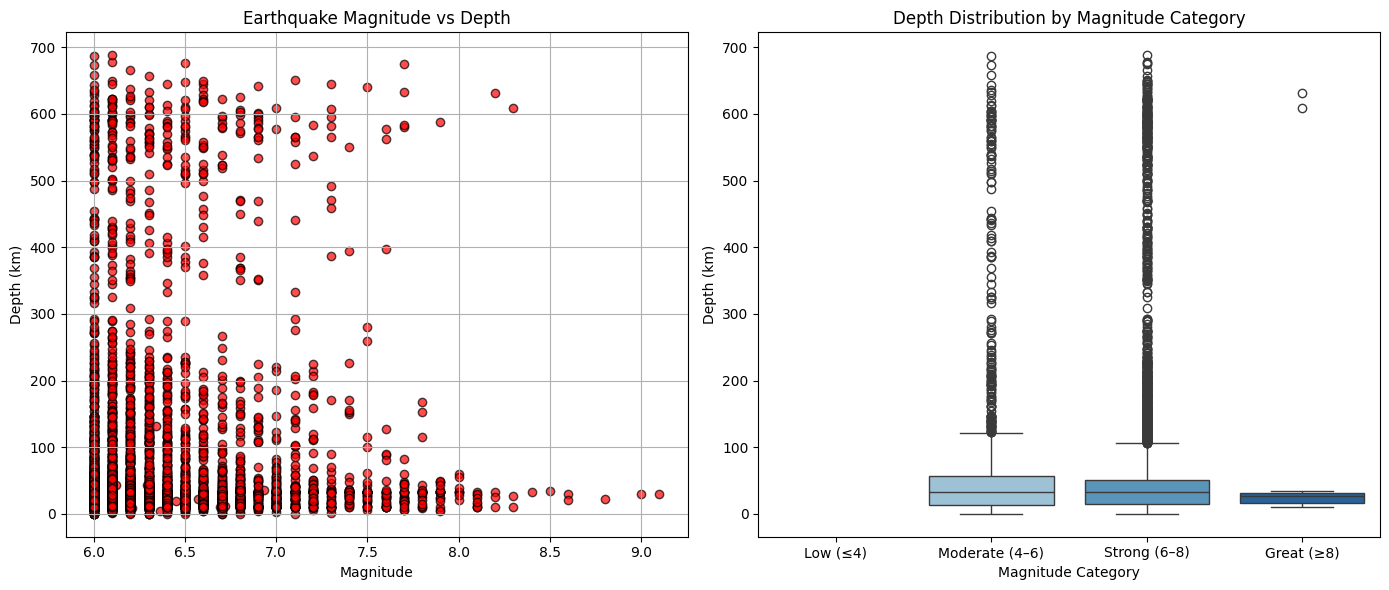

Pearson correlation (Depth vs Magnitude): 0.0129 → No Linear Relationship


In [27]:
mag = df["Magnitude"]
depth = df["Depth"]

# Define magnitude bins
bins = [0, 4.0, 6.0, 8.0, 10.0]
labels = ["Low (≤4)", "Moderate (4–6)", "Strong (6–8)", "Great (≥8)"]

# Create categorical column
df["Magnitude_cat"] = pd.cut(df["Magnitude"], bins=bins, labels=labels, include_lowest=True)

# Compute average depth per category
avg_depth_by_mag = df.groupby("Magnitude_cat")["Depth"].mean()

# Create 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Scatter plot (Magnitude vs Depth)
axes[0].scatter(mag, depth, c="red", alpha=0.7, edgecolors="black")
axes[0].set_xlabel("Magnitude")
axes[0].set_ylabel("Depth (km)")
axes[0].set_title("Earthquake Magnitude vs Depth")
axes[0].grid(True)

# Boxplot (Depth distribution by Magnitude category)
sns.boxplot(data=df, x="Magnitude_cat", y="Depth", palette="Blues", ax=axes[1])
axes[1].set_xlabel("Magnitude Category")
axes[1].set_ylabel("Depth (km)")
axes[1].set_title("Depth Distribution by Magnitude Category")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

corr = df["Magnitude"].corr(df["Depth"])
if abs(corr) < 0.1:
    verdict = "No Linear Relationship"
elif abs(corr) < 0.3:
    verdict = "Weak Linear Relationship"
elif abs(corr) < 0.5:
    verdict = "Moderate Linear Relationship"
else:
    verdict = "Strong Linear Relationship"

print(f"Pearson correlation (Depth vs Magnitude): {corr:.4f} → {verdict}")

# SEISMIC SOURCE

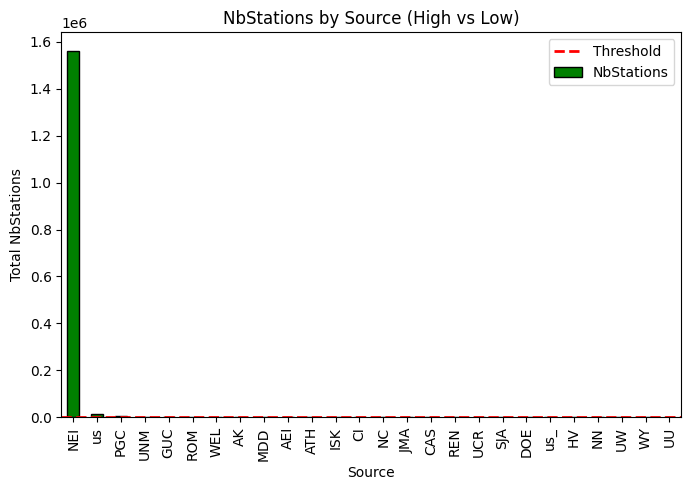

In [38]:
src_nbs = df.groupby("Source")["NbStations"].sum().sort_values(ascending=False) 
threshold = 400 
colors = ["green" if val >= threshold else "orange" for val in src_nbs] 
src_nbs.plot(kind="bar", figsize=(8,5), color=colors, edgecolor="black") 
plt.xlabel("Source") 
plt.ylabel("Total NbStations") 
plt.title("NbStations by Source (High vs Low)") 
plt.axhline(y=threshold, color="red", linestyle="--", linewidth=2, label="Threshold") 
plt.legend() 
plt.show()

# FINALLY, HEATMAP TO CHECK RELATIONSHIP BETWEEN COLUMNS

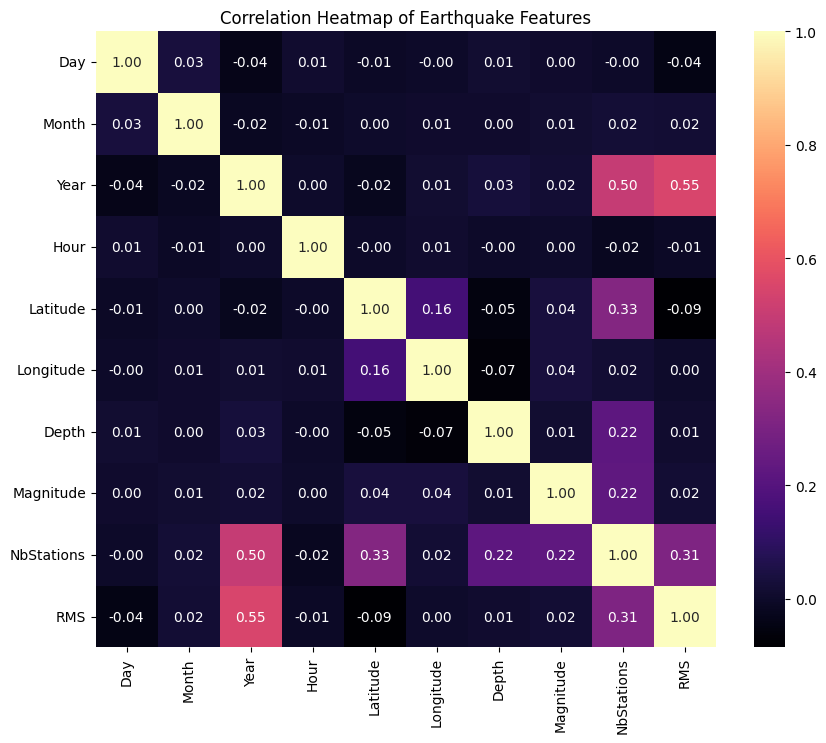

In [53]:
numeric_cols = ["Day","Month","Year","Hour","Latitude","Longitude","Depth","Magnitude","NbStations","RMS"]

# Compute correlation matrix
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="magma", fmt=".2f")
plt.title("Correlation Heatmap of Earthquake Features")
plt.show()

NbStations and RMS are >0.5 linear relationship with Year